In [1]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from bluemath_tk.datamining import PCA

#### Load ERA5 data

In [2]:
era5_data_2deg = xr.open_dataset('outputs/era5/sst_era5_2deg_masked.nc')

#### PCA

In [3]:
pca_ob = PCA(n_components = 0.95)
pca_ob.fit_transform(data = era5_data_2deg, vars_to_stack = ['sst'], coords_to_stack = ['latitude', 'longitude'], pca_dim_for_rows = 'time')

2026-06-11 16:42:15,964 - PCA - WARNING - Using 389 out of 14220 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 2MB
Dimensions:      (time: 31290, n_component: 6)
Coordinates:
  * time         (time) datetime64[ns] 250kB 1940-01-01 ... 2025-08-31
  * n_component  (n_component) int64 48B 0 1 2 3 4 5
    number       int64 8B ...
    surface      float64 8B ...
Data variables:
    PCs          (time, n_component) float64 2MB -12.92 -6.858 ... -0.02324
    stds         (n_component) float64 48B 17.94 5.338 3.382 2.015 1.713 1.458

In [4]:
era5_pcs = pca_ob.pcs_df

In [5]:
era5_pcs.to_csv('outputs/era5/era5_sst_pcs.csv')

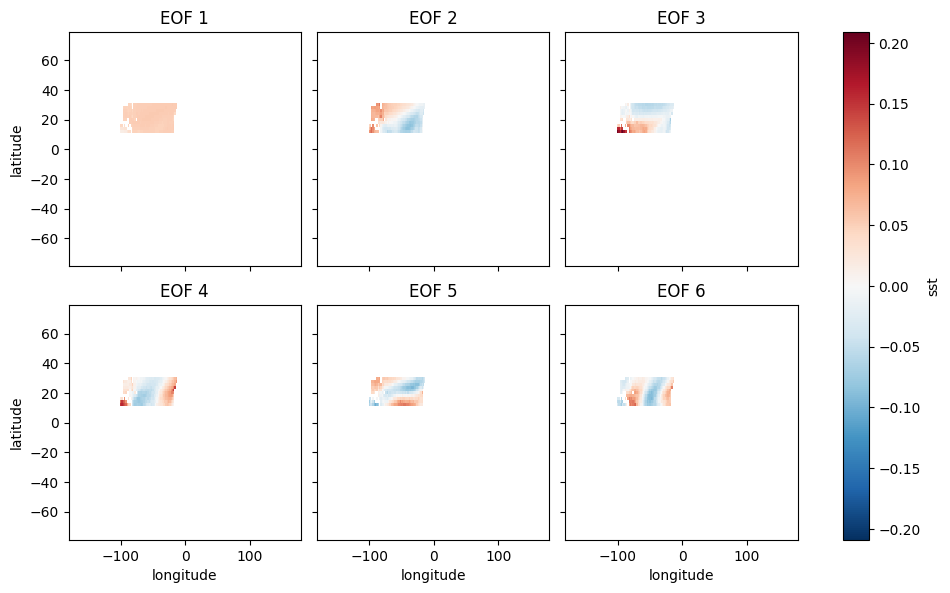

In [7]:
pca_ob.plot_eofs(vars_to_plot = ['sst'], num_eofs = 6)

#### GCM Projection

In [6]:
models = ['ec_earth3_veg_lr'] # ['ec_earth3_veg_lr', 'miroc6']
scenarios = ['historical', 'ssp245', 'ssp585']

Processing ec_earth3_veg_lr - historical


2026-05-07 09:56:41,101 - PCA - WARNING - Using 389 out of 14220 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


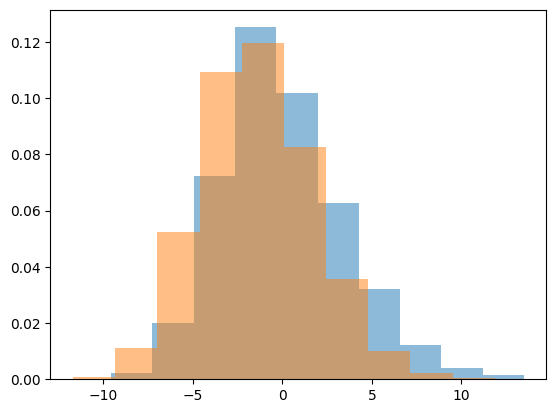

Processing ec_earth3_veg_lr - ssp245


2026-05-07 09:57:25,169 - PCA - WARNING - Using 389 out of 14220 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


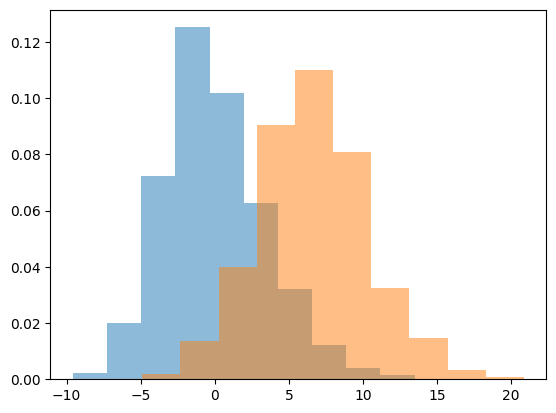

Processing ec_earth3_veg_lr - ssp585


2026-05-07 09:58:02,727 - PCA - WARNING - Using 389 out of 14220 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


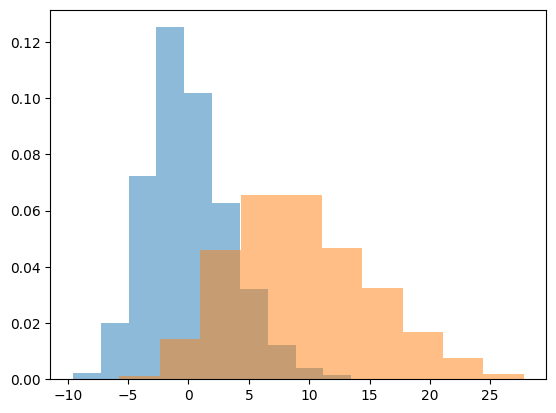

In [7]:
for model in models:
    for ssp in scenarios:
        
        print(f"Processing {model} - {ssp}")
        ds_gcm_sst = xr.open_dataset(f'outputs/cmip6_models/{model}/{ssp}/sst_{model}_{ssp}_2deg_masked_bias_corrected.nc')

        gcm_pca = pca_ob.transform(ds_gcm_sst)
        
        pcs_gcm = gcm_pca['PCs'].to_dataframe().unstack('n_component').drop(columns=['number','surface'])
        pcs_gcm.columns = [f"PC{i+1}" for i in range(pcs_gcm.shape[1])]

        pcs_gcm.to_csv(f'outputs/cmip6_models/{model}/{ssp}/sst_{model}_{ssp}_pcs.csv')

        pc = 2

        x = era5_pcs.iloc[:, pc]
        y = pcs_gcm.iloc[:, pc]

        plt.hist(x,density=True, alpha=0.5)
        plt.hist(y,density=True, alpha=0.5)

        plt.show()
